In [1]:
import pandas as pd
df=pd.read_excel('premiums.xlsx')
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


In [2]:
df.isna().sum()

Age                       0
Gender                    0
Region                    0
Marital_status            0
Number Of Dependants      0
BMI_Category              0
Smoking_Status           11
Employment_Status         2
Income_Level             13
Income_Lakhs              0
Medical History           0
Insurance_Plan            0
Annual_Premium_Amount     0
dtype: int64

In [3]:
df.Gender.unique(),df.Region.unique(),df.Marital_status.unique(),df.BMI_Category.unique(),df.Smoking_Status.unique(),df.Employment_Status.unique(),df.Income_Level.unique(),df['Medical History'].unique(),df.Insurance_Plan.unique()

(array(['Male', 'Female'], dtype=object),
 array(['Northwest', 'Southeast', 'Northeast', 'Southwest'], dtype=object),
 array(['Unmarried', 'Married'], dtype=object),
 array(['Normal', 'Obesity', 'Overweight', 'Underweight'], dtype=object),
 array(['No Smoking', 'Regular', 'Occasional', nan, 'Smoking=0',
        'Does Not Smoke', 'Not Smoking'], dtype=object),
 array(['Salaried', 'Self-Employed', 'Freelancer', nan], dtype=object),
 array(['<10L', '10L - 25L', '> 40L', '25L - 40L', nan], dtype=object),
 array(['Diabetes', 'High blood pressure', 'No Disease',
        'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
        'High blood pressure & Heart disease', 'Diabetes & Thyroid',
        'Diabetes & Heart disease'], dtype=object),
 array(['Bronze', 'Silver', 'Gold'], dtype=object))

In [4]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.593480,1.712080,23.018200,15768.116320
std,15.000437,1.498248,24.219197,8419.839675
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13929.000000
75%,45.000000,3.000000,31.000000,22275.250000
max,356.000000,5.000000,930.000000,43471.000000


In [5]:
df.shape

(50000, 13)

In [6]:
df.columns=df.columns.str.replace(' ','_').str.lower()
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365


# Handing na Values

In [7]:
df.isna().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [8]:
df.dropna(inplace=True) # size of dataset is very high and the na values are too low so we can drop na

In [9]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [10]:
print('Before: ',df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('After: ',df.duplicated().sum())

Before:  0
After:  0


In [11]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.711842,23.021150,15766.810189
std,15.000378,1.498195,24.221794,8419.995271
min,18.000000,-3.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


In [12]:
df[df.number_of_dependants<0]['number_of_dependants']

402     -3
2245    -3
2323    -3
2986    -1
3756    -1
        ..
48062   -1
48086   -1
49256   -1
49270   -1
49523   -1
Name: number_of_dependants, Length: 72, dtype: int64

In [13]:
df['number_of_dependants'].abs().loc[[402,2245,2323,2986,2756,5846]]

402     3
2245    3
2323    3
2986    1
2756    1
5846    3
Name: number_of_dependants, dtype: int64

In [14]:
df['number_of_dependants']=df['number_of_dependants'].abs()
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49976.000000,49976.000000,49976.000000,49976.000000
mean,34.591764,1.717284,23.021150,15766.810189
std,15.000378,1.491953,24.221794,8419.995271
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8607.750000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22273.500000
max,356.000000,5.000000,930.000000,43471.000000


In [15]:
numeric_cols=df.select_dtypes(['float64','int64']).columns
numeric_cols

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

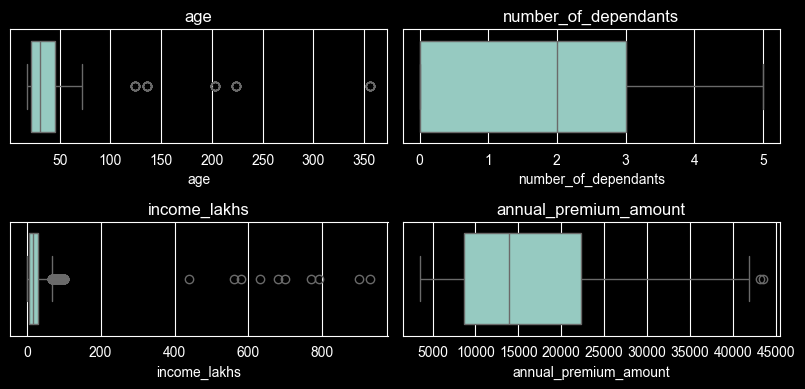

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

for i, col in enumerate(numeric_cols):
    plt.subplot((len(numeric_cols)+1)//2, 2, i+1)   # rows, columns, index
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [17]:
def get_iqr_bounds(col):
    q1,q3=col.quantile([0.25,0.75])
    iqr=q3-q1
    return (q1-1.5*iqr,q3+iqr*1.5)

In [18]:
df = df[df['age'] <= 100]

<Axes: xlabel='age'>

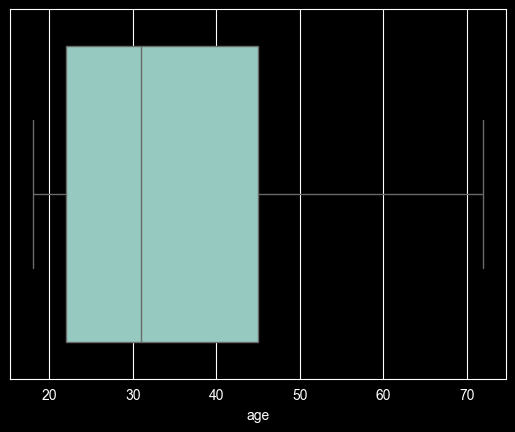

In [19]:
sns.boxplot(x=df['age'])

In [20]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,49918.000000,49918.000000,49918.000000,49918.000000
mean,34.401839,1.717617,23.025141,15766.589286
std,13.681600,1.492074,24.227912,8419.137327
min,18.000000,0.000000,1.000000,3501.000000
25%,22.000000,0.000000,7.000000,8608.000000
50%,31.000000,2.000000,17.000000,13928.000000
75%,45.000000,3.000000,31.000000,22272.000000
max,72.000000,5.000000,930.000000,43471.000000


<Axes: xlabel='income_lakhs', ylabel='Count'>

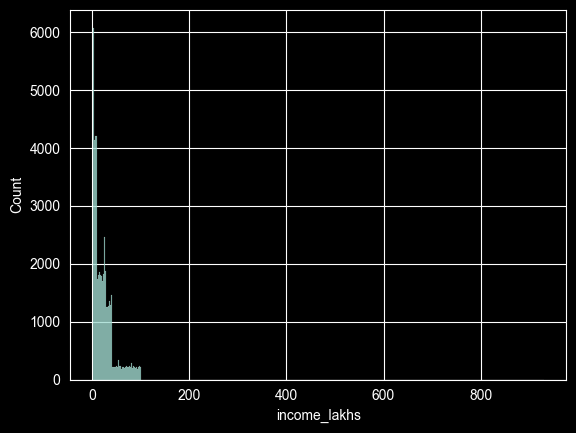

In [21]:
sns.histplot(df['income_lakhs'])

In [22]:
upper_income=get_iqr_bounds(df['income_lakhs'])[1] # the value we get is not that extreme so we try other things
quantile_threshold=df['income_lakhs'].quantile(0.999)
print(quantile_threshold)
df[df['income_lakhs']>quantile_threshold]['age'].count()

100.0


np.int64(10)

In [23]:
import numpy as np
df=df[df['income_lakhs']<=  quantile_threshold] # dropping the income greater than 100 because only 10 outliers

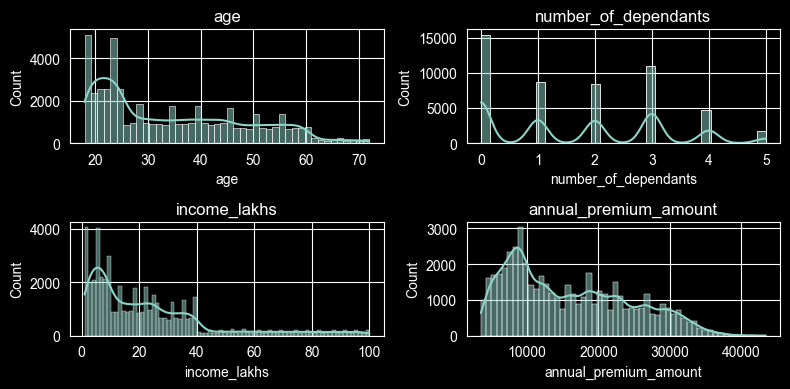

In [24]:
plt.figure(figsize=(8,4))
for i, col in enumerate(numeric_cols):
    plt.subplot((len(numeric_cols)+1)//2, 2, i+1)   # rows, columns, index
    sns.histplot(x=df[col],kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

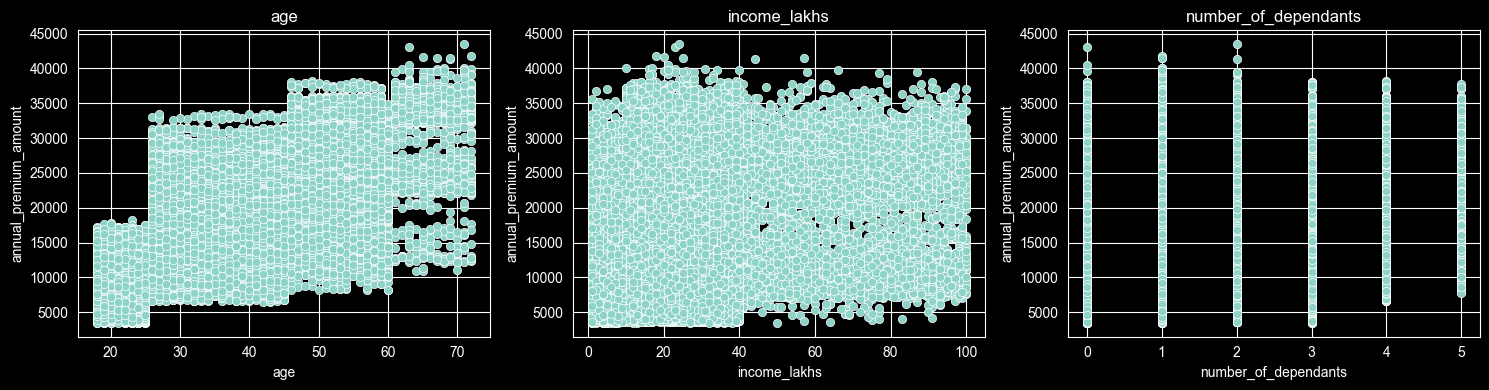

In [25]:
numeric_features = ['age','income_lakhs','number_of_dependants']
fig, axes = plt.subplots(1, len(numeric_features), figsize=(15,4))
for i, col in enumerate(numeric_features):
    sns.scatterplot(data=df, x=col, y='annual_premium_amount', ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [26]:
categorical_col=[ 'gender', 'region', 'marital_status','bmi_category', 'smoking_status', 'employment_status',  'medical_history', 'insurance_plan',]
for col in categorical_col:
    print(df[col].unique())

['Male' 'Female']
['Northwest' 'Southeast' 'Northeast' 'Southwest']
['Unmarried' 'Married']
['Normal' 'Obesity' 'Overweight' 'Underweight']
['No Smoking' 'Regular' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
['Salaried' 'Self-Employed' 'Freelancer']
['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
['Bronze' 'Silver' 'Gold']


In [27]:
df['smoking_status'].isna().sum()

np.int64(0)

In [28]:
df['smoking_status']=df['smoking_status'].replace({'Smoking=0':'No Smoking' ,'Does Not Smoke':'No Smoking','Not Smoking':'No Smoking'})

In [29]:
df['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [30]:
df['smoking_status'].value_counts()

smoking_status
No Smoking    27343
Regular       15664
Occasional     6901
Name: count, dtype: int64

In [31]:
df['gender'].value_counts(normalize=True),df['gender'].isna().sum()

(gender
 Male      0.549631
 Female    0.450369
 Name: proportion, dtype: float64,
 np.int64(0))

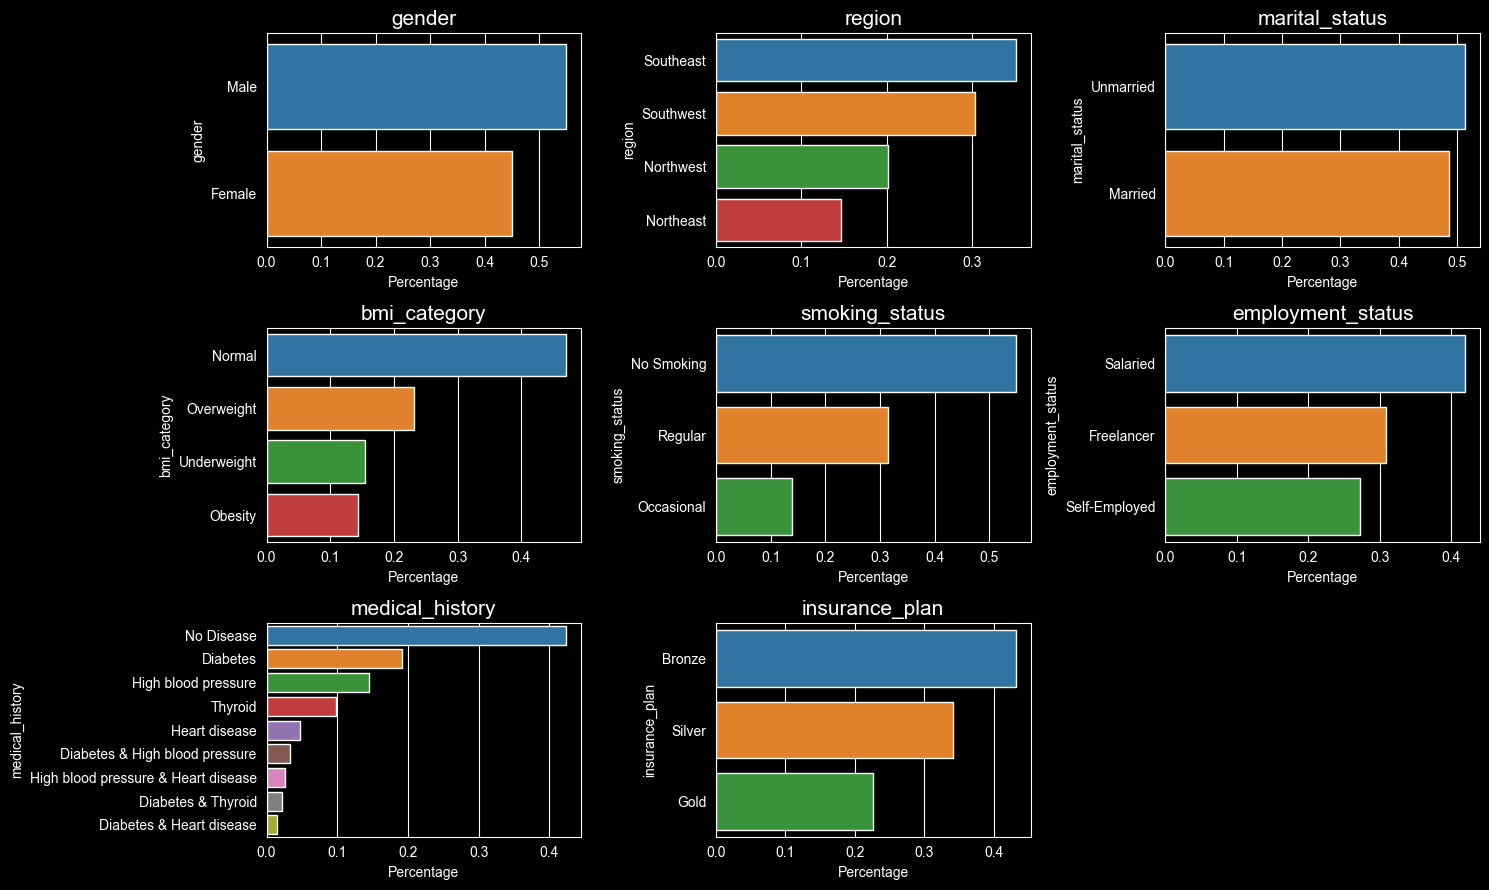

In [32]:
cols = categorical_col
n = len(cols)
rows = (n + 2) // 3   # calculate rows needed
fig, axes = plt.subplots(rows, 3, figsize=(15, 3*rows))
axes = axes.flatten()
for i, col in enumerate(cols):
    pct_count = df[col].value_counts(normalize=True)
    sns.barplot(x=pct_count.values,y=pct_count.index, ax=axes[i],hue=pct_count.index,palette='tab10')
    axes[i].set_title(col,fontsize=15)
    axes[i].set_xlabel("Percentage")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [33]:
crosstab=pd.crosstab(df['income_level'],df['insurance_plan'])
crosstab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,5307,3880,5182
25L - 40L,3683,2840,3750
<10L,12226,931,5486
> 40L,329,3653,2641


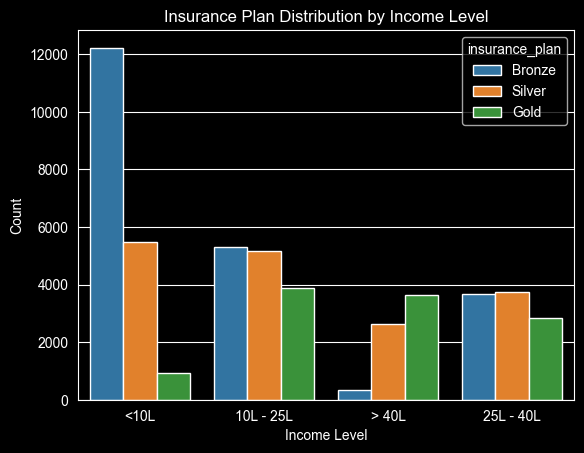

In [34]:
sns.countplot(data=df, x='income_level', hue='insurance_plan',palette='tab10')
plt.xlabel("Income Level")
plt.ylabel("Count")
plt.title("Insurance Plan Distribution by Income Level")
plt.show()

<Axes: xlabel='insurance_plan', ylabel='income_level'>

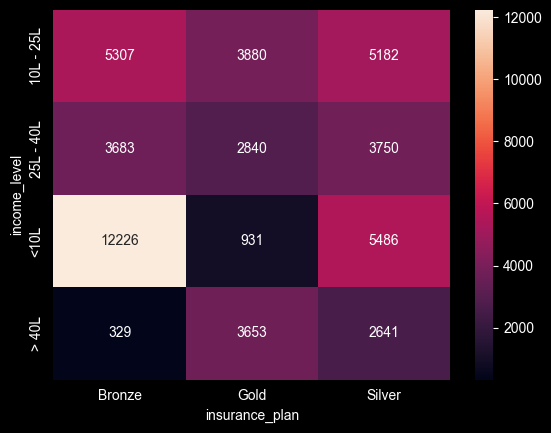

In [35]:
sns.heatmap(crosstab,annot=True,fmt="d")

In [36]:
df['medical_history'].unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [37]:
df[['disease1','disease2']]=df['medical_history'].str.split(" & ",expand=True).apply(lambda x: x.str.lower())
df.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
40067,25,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,8,No Disease,Bronze,9074,no disease,None
32036,41,Female,Southeast,Married,4,Normal,Occasional,Salaried,<10L,7,High blood pressure,Bronze,9883,high blood pressure,None
42907,44,Male,Northwest,Unmarried,0,Normal,Regular,Salaried,<10L,4,Diabetes,Bronze,12135,diabetes,None
14477,20,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,9,No Disease,Bronze,7848,no disease,None
40131,18,Female,Northwest,Unmarried,0,Normal,No Smoking,Freelancer,<10L,7,No Disease,Bronze,8748,no disease,None


In [38]:
df['disease1'].fillna('none',inplace=True)
df['disease2'].fillna('none',inplace=True)

In [39]:
risk_score={
    'diabetes':6,
    'heart disease':8,
    'high blood pressure':6,
    'thyroid':5,
    'no disease':0,
    'none':0
}

In [40]:
df['total_risk_score']=df['disease1'].map(risk_score)+df['disease2'].map(risk_score)

In [41]:
df.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score
9297,22,Male,Northwest,Unmarried,0,Underweight,No Smoking,Salaried,> 40L,58,No Disease,Silver,9211,no disease,none,0
30685,52,Female,Southeast,Married,2,Normal,No Smoking,Self-Employed,25L - 40L,38,Diabetes,Gold,26460,diabetes,none,6
33045,24,Female,Southwest,Unmarried,1,Obesity,No Smoking,Freelancer,<10L,4,No Disease,Bronze,9048,no disease,none,0
20920,52,Male,Northwest,Married,2,Obesity,Regular,Self-Employed,10L - 25L,22,Heart disease,Gold,37354,heart disease,none,8
38578,61,Female,Southeast,Married,1,Underweight,No Smoking,Salaried,10L - 25L,12,Diabetes,Gold,33452,diabetes,none,6


In [42]:
min_score=df['total_risk_score'].min()
max_score=df['total_risk_score'].max()
df['normalized_score']=((df['total_risk_score']-min_score)/(max_score-min_score))

In [43]:
df.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_score
19674,23,Male,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,<10L,5,No Disease,Bronze,5909,no disease,none,0,0.000000
24417,22,Female,Southeast,Unmarried,0,Obesity,No Smoking,Freelancer,<10L,7,No Disease,Bronze,6100,no disease,none,0,0.000000
10018,22,Male,Southwest,Married,3,Normal,No Smoking,Freelancer,<10L,7,Diabetes,Bronze,9001,diabetes,none,6,0.428571
17738,43,Female,Northeast,Unmarried,0,Overweight,Occasional,Salaried,25L - 40L,27,Diabetes,Silver,18918,diabetes,none,6,0.428571
13492,21,Female,Southwest,Unmarried,1,Normal,No Smoking,Freelancer,10L - 25L,18,Diabetes & High blood pressure,Silver,10724,diabetes,high blood pressure,12,0.857143


In [44]:
df2=df.copy()

In [45]:
df2['insurance_plan']=df2['insurance_plan'].map({'Bronze':1,'Silver':2,'Gold':3})

In [46]:
df2.insurance_plan.unique()

array([1, 2, 3])

In [47]:
df2.income_level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [48]:
df2['income_level']=df2['income_level'].map({'<10L':1, '10L - 25L':2, '> 40L':3, '25L - 40L':4})

In [49]:
df2['income_level'].unique()

array([1, 2, 3, 4])

In [50]:
nominal_cols=['gender', 'region', 'marital_status','bmi_category','smoking_status', 'employment_status']
df3=pd.get_dummies(df2,columns=nominal_cols,drop_first=True,dtype=int)

In [51]:
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,...,0,0,0,0,0,0,0,0,0,1
3,30,3,3,77,No Disease,3,20303,no disease,none,0,...,1,0,0,0,0,0,0,0,1,0
4,18,0,3,99,High blood pressure,2,13365,high blood pressure,none,6,...,0,0,1,0,1,0,0,1,0,1


In [52]:
df4=df3.drop(['medical_history','disease1','disease2','total_risk_score'],axis=1)
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,3,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,18,0,3,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1


In [53]:
correlation=df4.corr()
correlation

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
age,1.000000,0.415742,0.026606,0.025060,0.496317,0.767569,0.442773,-0.002219,0.000464,0.003305,-0.003424,-0.543104,0.152496,0.153148,-0.115888,0.066596,0.059380,-0.008093,0.314684
number_of_dependants,0.415742,1.000000,0.003396,0.006074,0.256459,0.414691,0.371498,-0.003093,0.001693,0.003620,-0.000339,-0.841717,0.115397,0.110451,-0.093881,0.071762,0.094829,0.067066,0.115930
income_level,0.026606,0.003396,1.000000,0.667679,0.328676,0.218786,0.013994,0.076983,-0.001584,-0.000751,0.006052,-0.009684,-0.006561,0.007643,-0.002392,-0.006054,0.026165,-0.173722,0.154917
income_lakhs,0.025060,0.006074,0.667679,1.000000,0.410753,0.243058,0.009626,0.039126,-0.005192,-0.001250,0.009929,-0.011099,0.000314,0.007150,-0.000740,0.002306,0.010948,-0.100510,0.109759
insurance_plan,0.496317,0.256459,0.328676,0.410753,1.000000,0.834148,0.260932,0.034211,-0.002821,0.004082,-0.000977,-0.316800,0.094698,0.098639,-0.073881,0.037351,0.059587,-0.041582,0.223947
annual_premium_amount,0.767569,0.414691,0.218786,0.243058,0.834148,1.000000,0.519458,0.064470,-0.005078,0.008235,-0.003828,-0.516350,0.249847,0.187103,-0.135289,0.060610,0.198829,-0.005442,0.289438
normalized_score,0.442773,0.371498,0.013994,0.009626,0.260932,0.519458,1.000000,-0.003754,-0.005627,0.002019,-0.000132,-0.433916,0.101039,0.102556,-0.087996,0.071090,0.093822,0.059511,0.135824
gender_Male,-0.002219,-0.003093,0.076983,0.039126,0.034211,0.064470,-0.003754,1.000000,-0.003287,-0.002988,0.001873,0.003944,-0.031351,0.080588,-0.043000,-0.045618,0.305180,0.005559,0.001055
region_Northwest,0.000464,0.001693,-0.001584,-0.005192,-0.002821,-0.005078,-0.005627,-0.003287,1.000000,-0.368277,-0.330654,-0.001083,-0.002262,0.001194,-0.002017,-0.000669,-0.000255,0.004574,0.000110
region_Southeast,0.003305,0.003620,-0.000751,-0.001250,0.004082,0.008235,0.002019,-0.002988,-0.368277,1.000000,-0.484271,-0.003980,0.006373,0.002511,0.000211,-0.002191,-0.000401,-0.006575,0.003287


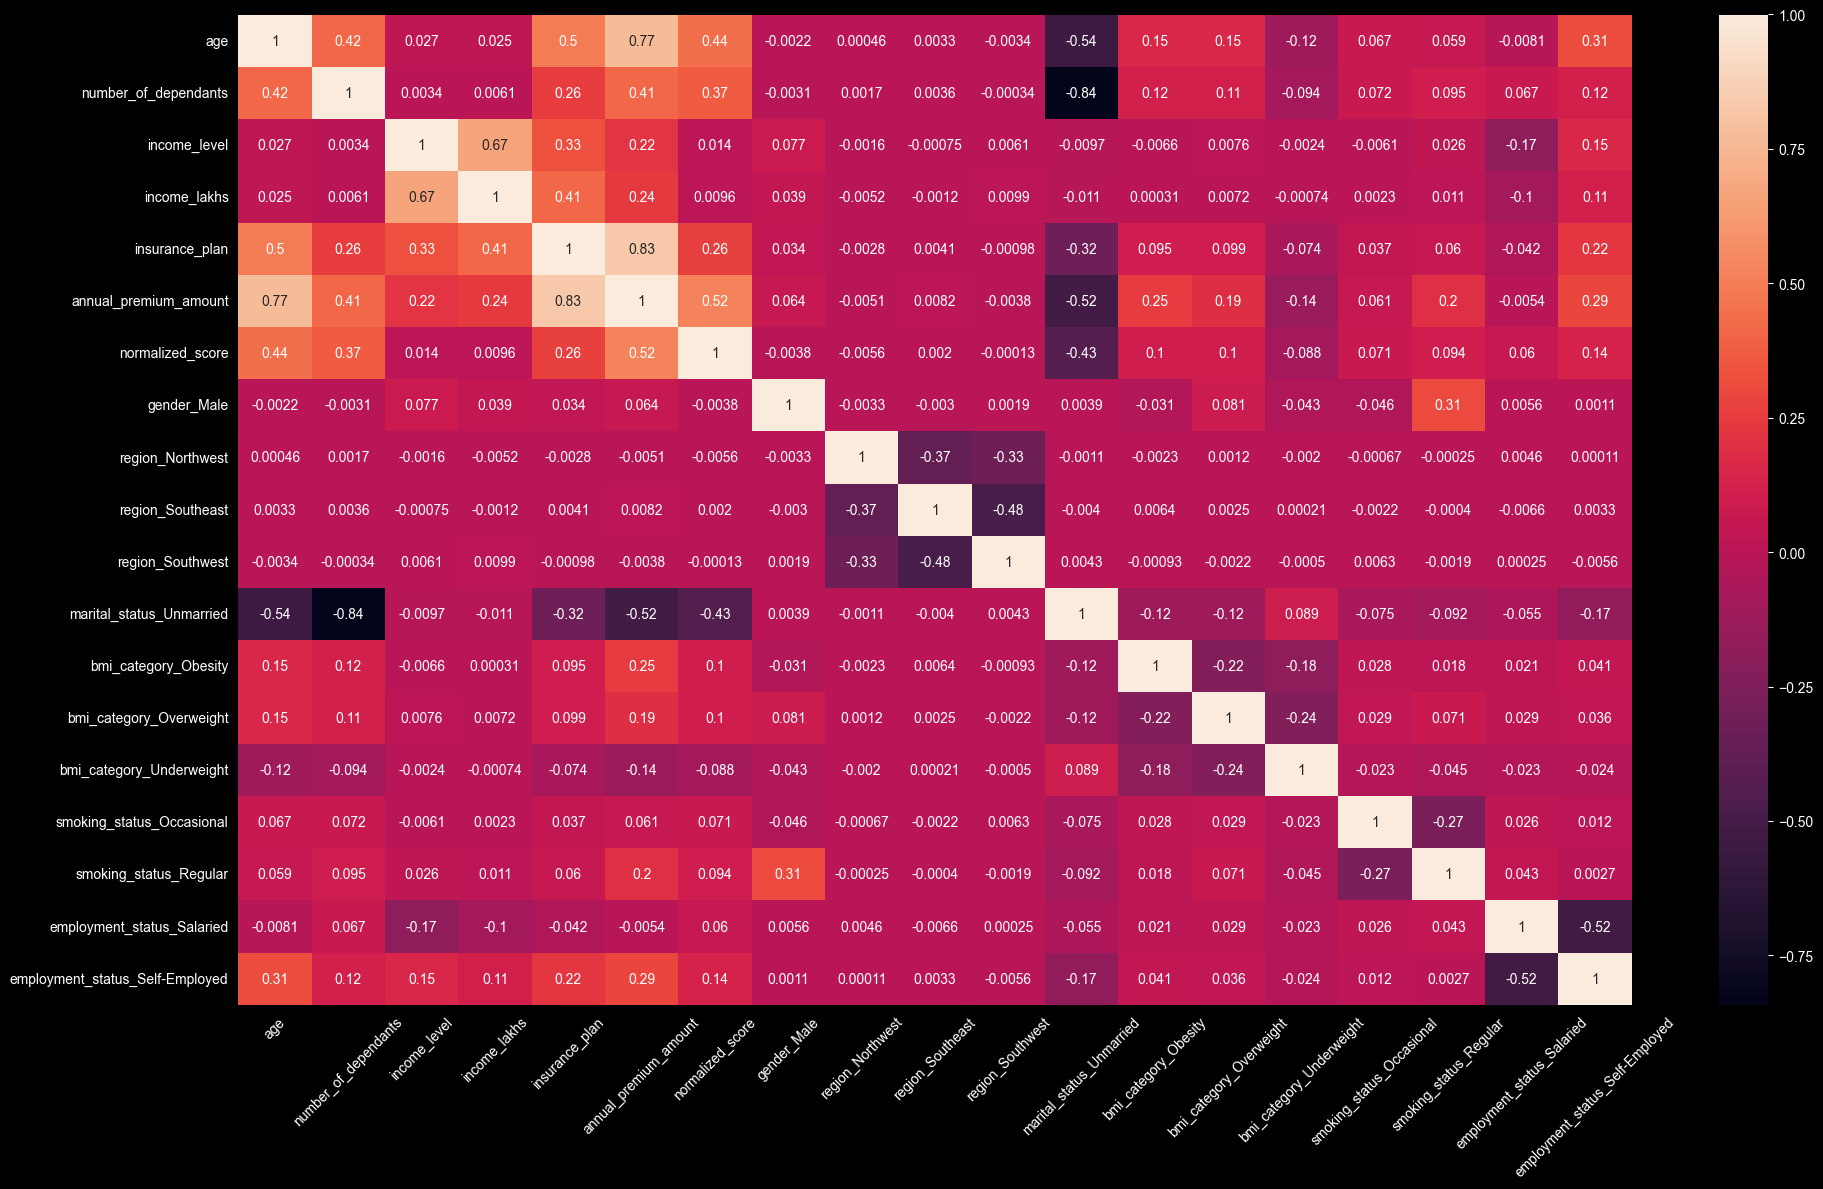

In [54]:
plt.figure(figsize=(20,12))
sns.heatmap(correlation,annot=True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
x=df4.drop(['annual_premium_amount'],axis=1)
y=df4['annual_premium_amount']
from sklearn.preprocessing import MinMaxScaler
cols_to_scale=['age', 'number_of_dependants', 'income_level', 'income_lakhs','insurance_plan']
scalar=MinMaxScaler()
x[cols_to_scale]=scalar.fit_transform(x[cols_to_scale])
x.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.00000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000,49908.000000
mean,0.303733,0.343528,0.390278,0.221110,0.397401,0.291831,0.549631,0.20093,0.350385,0.303038,0.513545,0.143183,0.231245,0.155326,0.138274,0.313857,0.419412,0.272041
std,0.253363,0.298406,0.380124,0.223946,0.392459,0.287420,0.497536,0.40070,0.477095,0.459576,0.499822,0.350263,0.421633,0.362219,0.345191,0.464064,0.493468,0.445015
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.074074,0.000000,0.000000,0.060606,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.240741,0.400000,0.333333,0.161616,0.500000,0.357143,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.500000,0.600000,0.666667,0.303030,0.500000,0.428571,1.000000,0.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def vif(data):
    vif_df=pd.DataFrame()
    vif_df['features']=data.columns
    vif_df['vif']=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [57]:
vif(x)

,features,vif
0,age,4.546828
1,number_of_dependants,4.552788
2,income_level,3.809392
3,income_lakhs,3.940341
4,insurance_plan,3.470028
5,normalized_score,2.688740
6,gender_Male,2.424683
7,region_Northwest,2.103537
8,region_Southeast,2.923930
9,region_Southwest,2.671921


In [58]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [59]:
from sklearn.linear_model import LinearRegression
model_lr=LinearRegression()
model_lr.fit(x_train,y_train)
train_score=model_lr.score(x_train,y_train)
test_score=model_lr.score(x_test,y_test)
train_score,test_score

(0.929020299691518, 0.9276834356252578)

In [60]:
x.columns,model_lr.coef_

(Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
        'insurance_plan', 'normalized_score', 'gender_Male', 'region_Northwest',
        'region_Southeast', 'region_Southwest', 'marital_status_Unmarried',
        'bmi_category_Obesity', 'bmi_category_Overweight',
        'bmi_category_Underweight', 'smoking_status_Occasional',
        'smoking_status_Regular', 'employment_status_Salaried',
        'employment_status_Self-Employed'],
       dtype='object'),
 array([11260.13539144,  -532.95518876,   727.79462099, -1135.8508156 ,
        12465.58684061,  4836.15849468,   112.07892916,   -53.55277726,
           25.00181407,   -19.43958593,  -834.28611368,  3376.46749858,
         1603.68878166,   349.20550654,   723.92451579,  2248.20833531,
          202.27371403,   367.98692559]))

In [61]:
feature_importance=pd.DataFrame(model_lr.coef_,index=x.columns,columns=['coefficient'])
feature_importance.sort_values(by='coefficient',ascending=True,inplace=True)
feature_importance

,coefficient
income_lakhs,-1135.850816
marital_status_Unmarried,-834.286114
number_of_dependants,-532.955189
region_Northwest,-53.552777
region_Southwest,-19.439586
region_Southeast,25.001814
gender_Male,112.078929
employment_status_Salaried,202.273714
bmi_category_Underweight,349.205507
employment_status_Self-Employed,367.986926


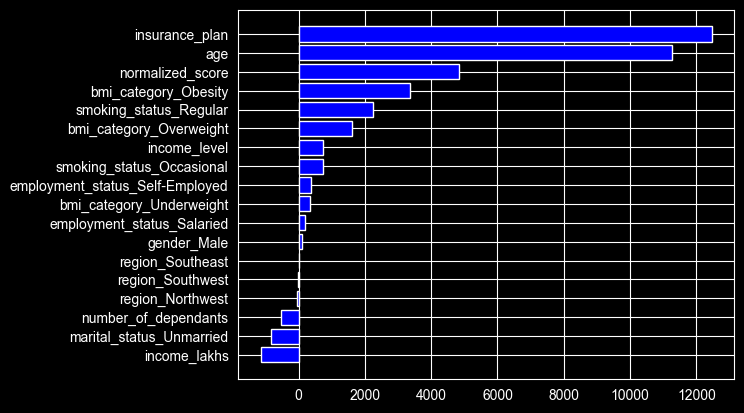

In [62]:
plt.barh(feature_importance.index,feature_importance['coefficient'],color='blue')
plt.show()

In [63]:
from sklearn.linear_model import Ridge
model_rg=Ridge()
model_rg.fit(x_train,y_train)
train_score=model_rg.score(x_train,y_train)
test_score=model_rg.score(x_test,y_test)
train_score,test_score

(0.9290202697087914, 0.9276827442376581)

In [64]:
from sklearn.tree import DecisionTreeRegressor
model_dt=DecisionTreeRegressor()
model_dt.fit(x_train,y_train)
train_score=model_dt.score(x_train,y_train)
test_score=model_dt.score(x_test,y_test)
train_score,test_score

(0.9991360196081306, 0.9638272789695279)

In [65]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,root_mean_squared_error
model_xg=XGBRegressor()
model_xg.fit(x_train,y_train)
y_pred=model_xg.predict(x_test)
train_score=model_xg.score(x_train,y_train)
test_score=model_xg.score(x_test,y_test)
train_score,test_score,mean_squared_error(y_test,y_pred),root_mean_squared_error(y_test,y_pred)

(0.9858680367469788, 0.9810478091239929, 1335419.25, 1155.6033935546875)

In [66]:
from sklearn.model_selection import GridSearchCV
params={
    "n_estimators":  [20,40,50],
    'learning_rate': [0.01,0.1,0.2],
    'max_depth': [3,4,5]
}
grid=GridSearchCV(estimator=model_xg,param_grid=params,scoring='r2',cv=10,n_jobs=-1)
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [20, 40, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [67]:
grid.score(x_test,y_test)

0.9818776249885559

In [68]:
grid.best_score_

np.float64(0.9819671273231506)

In [69]:
best_model=grid.best_estimator_

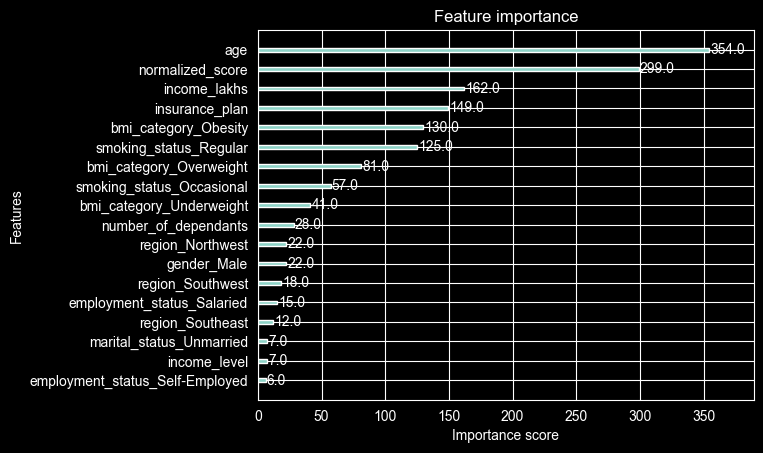

In [70]:
import xgboost as xgb
xgb.plot_importance(best_model)
plt.show()

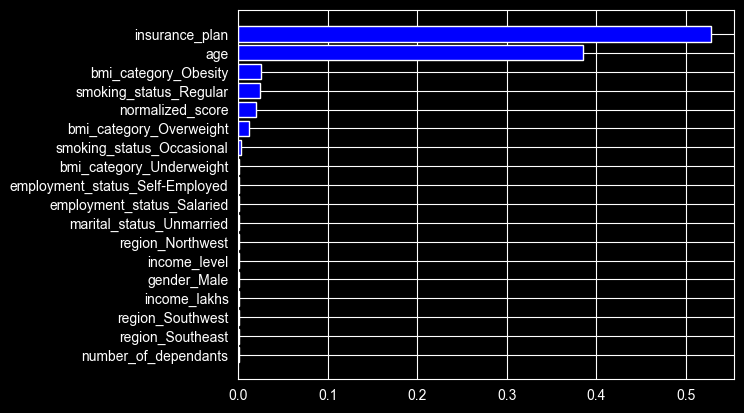

In [71]:
feature_importance=pd.DataFrame(best_model.feature_importances_,columns=['coefficient'],index=x_test.columns)
feature_importance.sort_values(by='coefficient',ascending=True,inplace=True)
plt.barh(feature_importance.index,feature_importance['coefficient'],color='blue')
plt.show()

In [76]:
y_pred=best_model.predict(x_test)
residual=y_pred-y_test
residual_pct=residual*100/y_test
result_df=pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residual,
    'diff_pct':residual_pct
})
result_df.head()

,actual,predicted,diff,diff_pct
24098,9246,9155.202148,-90.797852,-0.982023
201,11664,13326.610352,1662.610352,14.254204
25471,10472,7361.542480,-3110.457520,-29.702612
32500,26267,25996.023438,-270.976562,-1.031624
30832,9106,9174.112305,68.112305,0.747994


In [89]:
result_df[result_df['diff_pct']>10].sample(5)

,actual,predicted,diff,diff_pct
12169,5822,6977.069336,1155.069336,19.839734
22020,4944,7052.181152,2108.181152,42.641205
3497,10076,11588.537109,1512.537109,15.011285
9227,4486,7040.793457,2554.793457,56.950367
35942,12147,15462.614258,3315.614258,27.295746


<Axes: xlabel='diff_pct', ylabel='Count'>

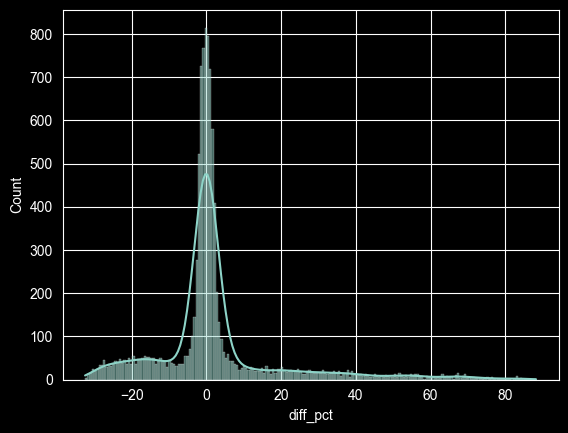

In [92]:
sns.histplot(result_df['diff_pct'],kde=True)

In [104]:
extreme_error_threshold=10
extreme_result_df=result_df[abs(result_df['diff_pct'])>extreme_error_threshold]
extreme_result_df.head()

,actual,predicted,diff,diff_pct
201,11664,13326.610352,1662.610352,14.254204
25471,10472,7361.542480,-3110.457520,-29.702612
47939,11996,13588.979492,1592.979492,13.279256
26239,4436,6519.667969,2083.667969,46.971776
16907,8952,10940.061523,1988.061523,22.208015


In [107]:
extreme_error_pct=extreme_result_df.shape[0]*100/result_df.shape[0]
extreme_error_pct

28.7818072530555

In [113]:
result_df[np.abs(result_df['diff_pct'])>50].sort_values(by='diff_pct',ascending=False)

,actual,predicted,diff,diff_pct
37745,3890,7320.398926,3430.398926,88.185062
29904,3503,6588.937012,3085.937012,88.094120
23975,3520,6572.304199,3052.304199,86.713187
42342,3521,6548.146973,3027.146973,85.974069
10288,3517,6538.154297,3021.154297,85.901459
...,...,...,...,...
29632,4315,6492.770508,2177.770508,50.469768
39548,4449,6685.653809,2236.653809,50.273181
36594,4493,6746.635254,2253.635254,50.158808
5247,4788,7188.794922,2400.794922,50.141916


In [118]:
extreme_error_df=x_test.loc[extreme_result_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
201,0.129630,0.2,0.666667,0.636364,1.0,0.0,0,1,0,0,1,0,0,0,0,0,0,0
25471,0.074074,0.0,0.000000,0.010101,0.0,0.0,1,1,0,0,1,0,1,0,0,1,1,0
47939,0.111111,0.0,0.666667,0.424242,1.0,0.0,0,1,0,0,1,0,0,1,0,0,1,0
26239,0.037037,0.0,1.000000,0.292929,0.0,0.0,1,1,0,0,1,0,0,1,0,0,0,0
16907,0.111111,0.0,0.666667,0.606061,0.5,0.0,1,0,0,0,1,0,0,1,0,1,0,0


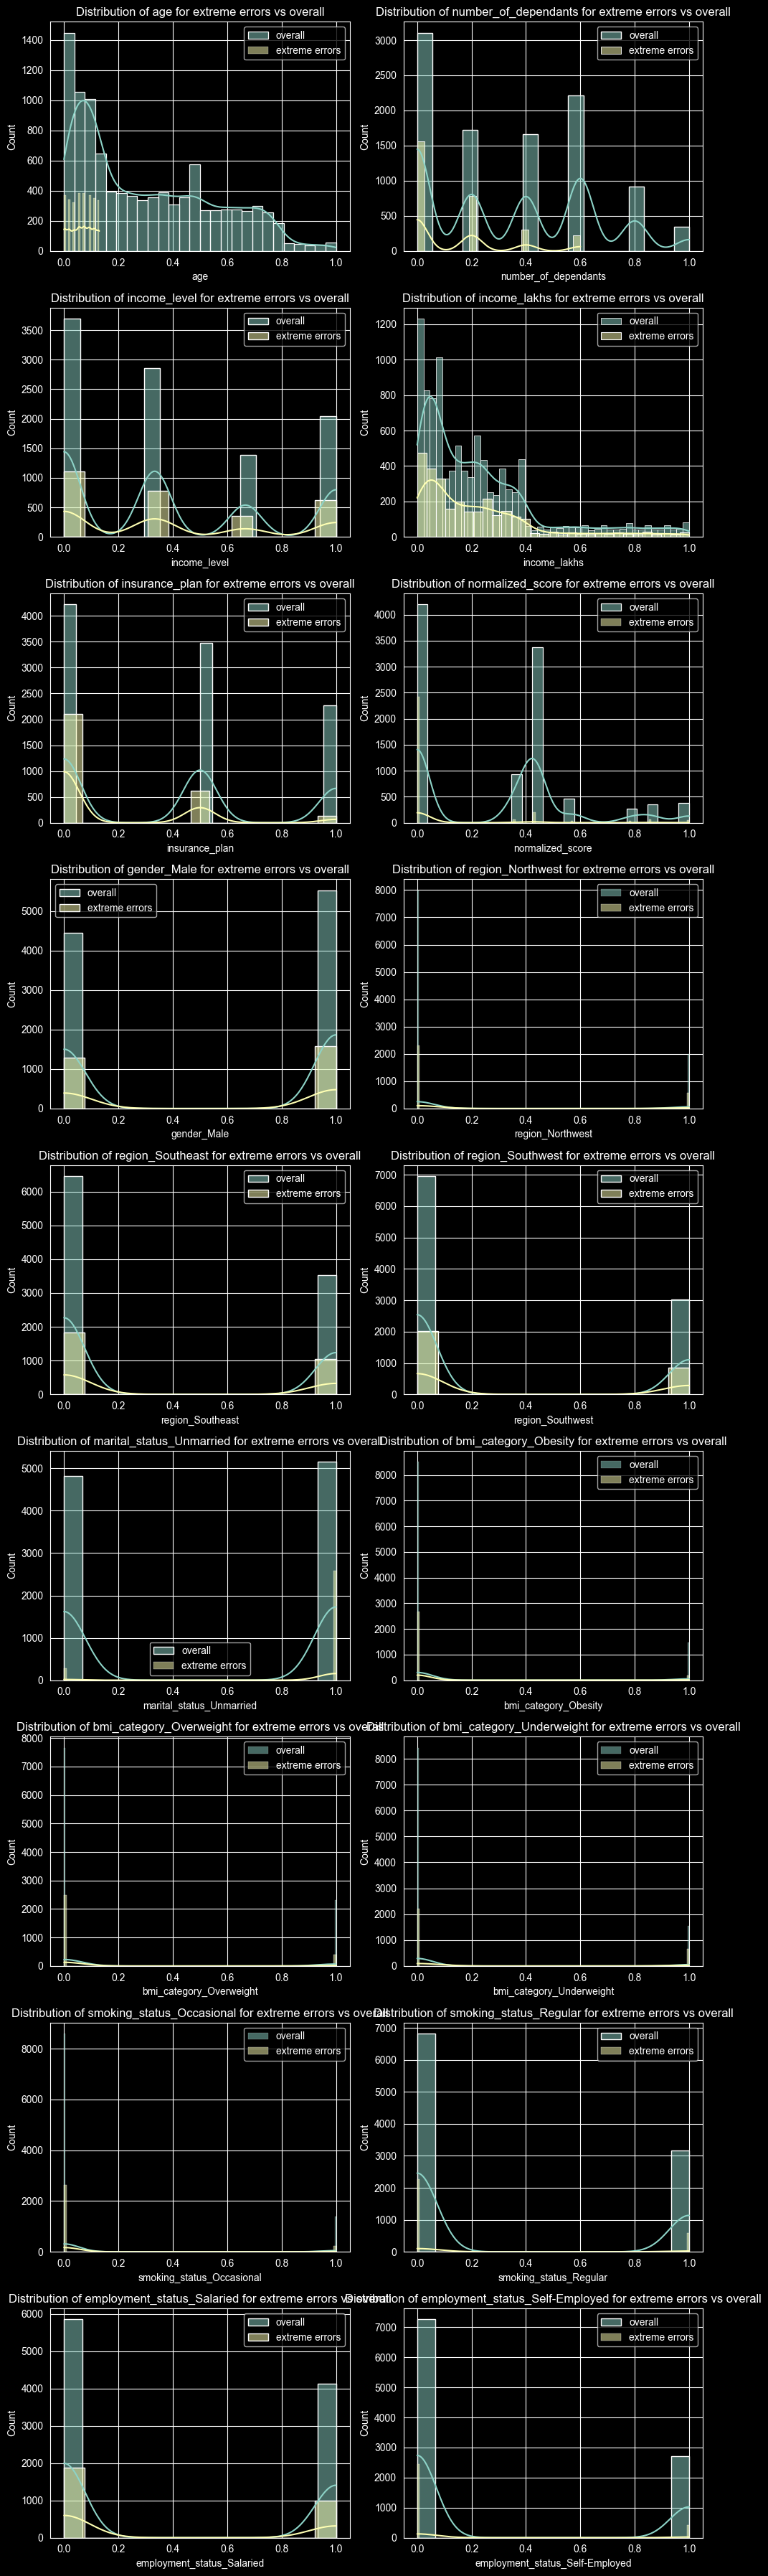

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
cols = 2
rows = int(np.ceil(len(x_test.columns) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5*cols,4*rows))
axes = axes.flatten()
for i, feature in enumerate(x_test.columns):
    sns.histplot(x_test[feature], kde=True, label='overall', ax=axes[i])
    sns.histplot(extreme_error_df[feature], kde=True, label='extreme errors', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature} for extreme errors vs overall')
    axes[i].legend()
plt.tight_layout()
plt.show()

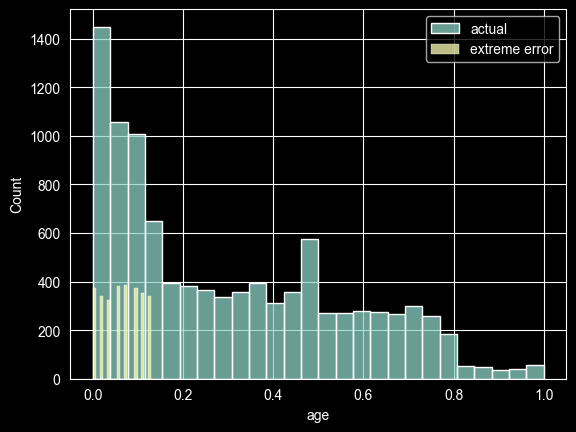

In [144]:
sns.histplot(x_test.age,label='actual')
sns.histplot(extreme_error_df.age,label='extreme error')
plt.legend()
plt.show()

In [166]:
df_reversed=pd.DataFrame(scalar.inverse_transform(extreme_error_df[cols_to_scale]),columns=cols_to_scale)
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
0,25.0,1.0,3.0,64.0,3.0
1,22.0,0.0,1.0,2.0,1.0
2,24.0,0.0,3.0,43.0,3.0
3,20.0,0.0,4.0,30.0,1.0
4,24.0,0.0,3.0,61.0,2.0


<Axes: xlabel='age', ylabel='Count'>

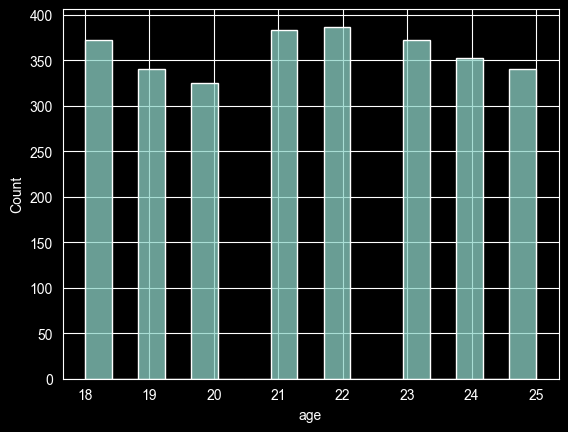

In [170]:
sns.histplot(df_reversed['age'])

In [173]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,2873.000000,2873.000000,2873.000000,2873.000000,2873.000000
mean,21.496693,0.716672,2.172294,22.423599,1.313958
std,2.271617,0.937714,1.161972,21.643827,0.558802
min,18.000000,0.000000,1.000000,1.000000,1.000000
25%,20.000000,0.000000,1.000000,6.000000,1.000000
50%,22.000000,0.000000,2.000000,16.000000,1.000000
75%,23.000000,1.000000,3.000000,31.000000,2.000000
max,25.000000,3.000000,4.000000,100.000000,3.000000
